## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor



## 1. Carga datos y representa la serie

In [86]:
pasajeros = pd.read_csv('data/AirPassengers.csv')
pasajeros.head()


,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


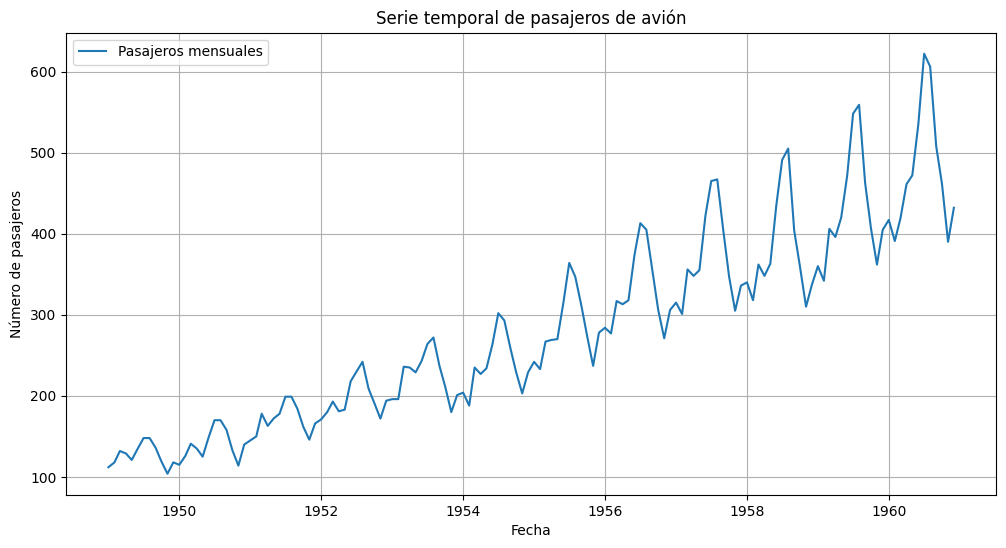

In [87]:
pasajeros['date'] = pd.to_datetime(pasajeros['date'])
pasajeros.set_index('date', inplace=True)
pasajeros = pasajeros.asfreq('MS')


plt.figure(figsize=(12,6))
plt.plot(pasajeros['value'], label='Pasajeros mensuales')
plt.title('Serie temporal de pasajeros de avión')
plt.xlabel('Fecha')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.grid()
plt.show()


Si, hay estacionalidad, hay un aumento significativo en el numero de pasajajeros a dos veces por bracket y teniendo en cuneta su posición y que cada bracket corresponde a dos años, podemos deducir que se asocia a los meses de Agosto/Julio o Agosto/Septiembre, meses en los que la gente viaja mas debido al verano. 

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

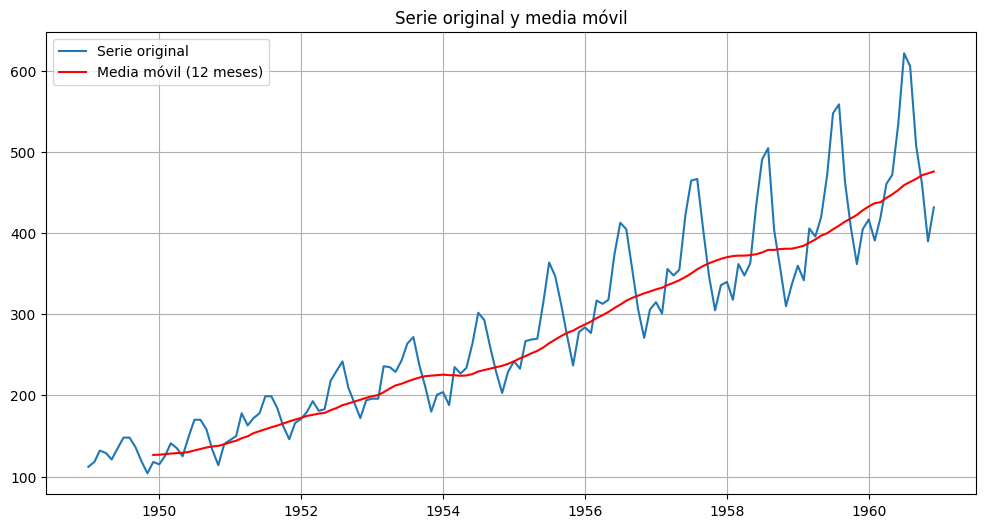

In [88]:
media_movil_12_meses = pasajeros['value'].rolling(window=12).mean()

plt.figure(figsize=(12,6))
plt.plot(pasajeros['value'], label='Serie original')
plt.plot(media_movil_12_meses, label='Media móvil (12 meses)', color='red')
plt.title('Serie original y media móvil')
plt.legend()
plt.grid()
plt.show()

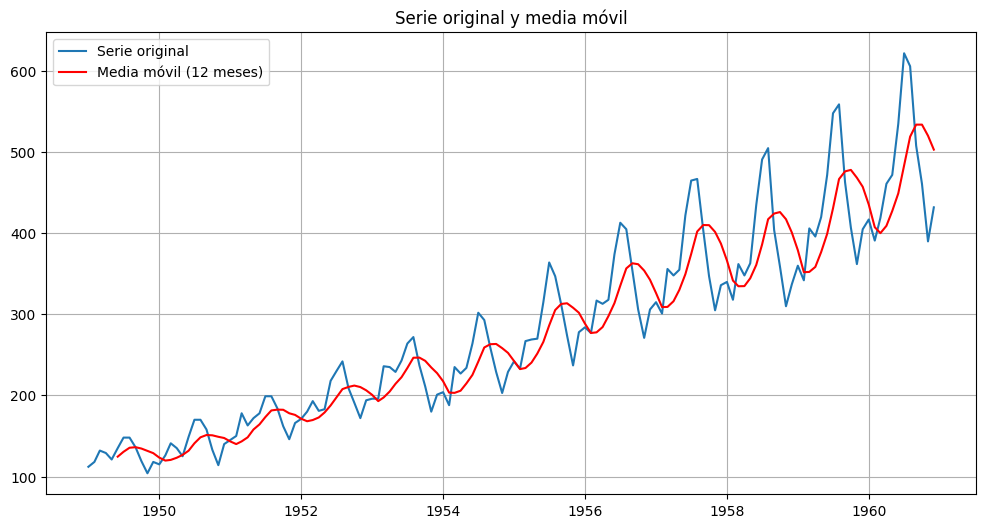

In [89]:
media_movil_6_meses = pasajeros['value'].rolling(window=6).mean()

plt.figure(figsize=(12,6))
plt.plot(pasajeros['value'], label='Serie original')
plt.plot(media_movil_6_meses, label='Media móvil (12 meses)', color='red')
plt.title('Serie original y media móvil')
plt.legend()
plt.grid()
plt.show()

## 3. Comprueba de manera estadística si la serie es o no estacionaria.

In [90]:
resultado = adfuller(pasajeros['value'])
print('ADF Statistic:', resultado[0])
print('p-value:', resultado[1])

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


In [91]:
resultado2 = kpss(pasajeros['value'], regression='c', nlags='auto')
print('KPSS Statistic:', resultado2[0])
print('p-value:', resultado2[1])

KPSS Statistic: 1.6513122354165206
p-value: 0.01


C:\Users\Jon\AppData\Local\Temp\ipykernel_1456\4259328451.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado2 = kpss(pasajeros['value'], regression='c', nlags='auto')


Para ADF, el p-valor es muy alto (> 0.05), por lo tanto no podemos rechazar la hipótesis nula de que la serie tiene raíz unitaria, es decir: la serie no es estacionaria. En el caso de KPSS, al tener un p-valor menor que 0.05 (0.01 en nuestro caso), rechazamos la hipótesis nula de que la serie si es estacionaria, confirmando el resultaddo que hemos obtenido anteriormente. 

## 4. Aplica una transformación logarítmica

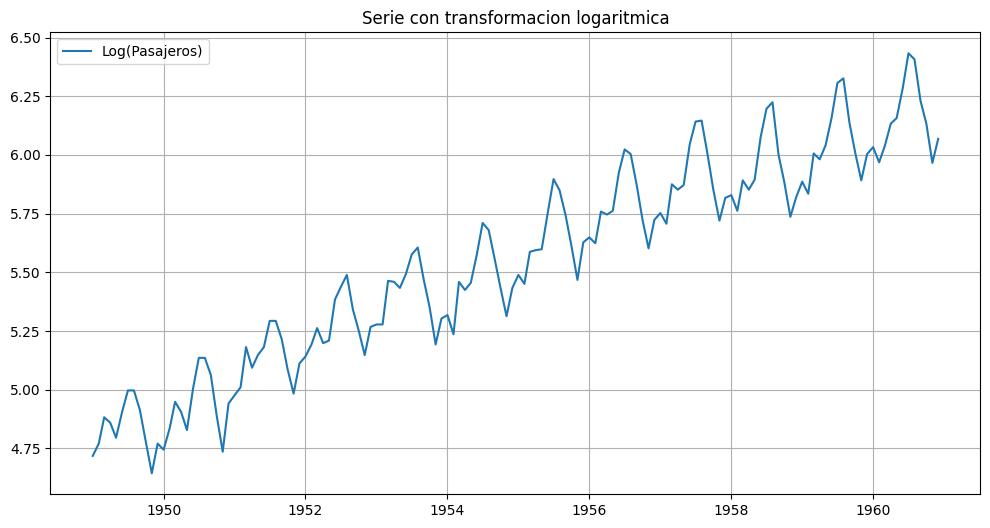

In [92]:
pasajeros['valor_log'] = np.log(pasajeros['value'])

# Visualización de la serie logarítmica
plt.figure(figsize=(12, 6))
plt.plot(pasajeros['valor_log'], label='Log(Pasajeros)')
plt.title('Serie con transformacion logaritmica')
plt.legend()
plt.grid()
plt.show()

## 5. Divide en train y test. Guarda 20 muestras para test.

In [93]:
train = pasajeros['valor_log'][:-20]
test = pasajeros['valor_log'][-20:]

## 6. Crea tu primer modelo ARIMA

In [94]:
modelo = ARIMA(train, order=(2,1,2), seasonal_order=(1,1,1,12))
modelo_fit = modelo.fit(method_kwargs={"maxiter": 1000})

prediccion_logaritmica = modelo_fit.forecast(steps=20)
prediccion = np.exp(prediccion_logaritmica)
real = np.exp(test)

mae = mean_absolute_error(real, prediccion)
mse = np.sqrt(mean_squared_error(real,prediccion))

print(f"MAE del modelo ARIMA: {mae:.2f}")
print(f"MSE del modelo ARIMA: {mse:.2f}")


MAE del modelo ARIMA: 18.50
MSE del modelo ARIMA: 20.16


## 7. Representa en una gráfica los datos de test y tus predicciones.

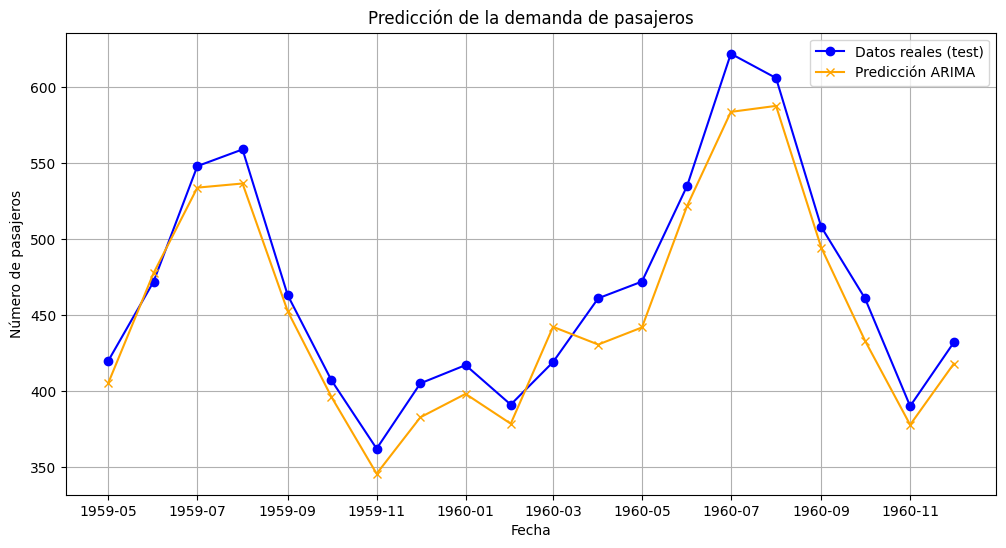

In [95]:
plt.figure(figsize=(12,6))
plt.plot(real.index, real, label='Datos reales (test)', marker='o', color='blue')
plt.plot(real.index, prediccion, label='Predicción ARIMA', marker='x', color='orange')
plt.title('Predicción de la demanda de pasajeros')
plt.xlabel('Fecha')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.grid(True)
plt.show()

## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

In [96]:
def crear_lags(series, n_lags):
    df = pd.DataFrame(series)
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = df['value'].shift(lag)
    df = df.dropna()
    return df

pasajeros_lags = crear_lags(pasajeros, 12)  
train_modelos = pasajeros_lags.iloc[:-20]
test_modelos = pasajeros_lags.iloc[-20:]

X_train = train_modelos.drop('value', axis=1)
y_train = train_modelos['value']
X_test = test_modelos.drop('value', axis=1)
y_test = test_modelos['value']



#### Modelo de Decision tree

In [97]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = np.sqrt(mean_squared_error(y_test,y_pred_dt))
print(f"Decision Tree MAE: {mae_dt:.2f}")
print(f"Decision Tree MSE: {mse_dt:.2f}")





Decision Tree MAE: 30.40
Decision Tree MSE: 46.27


#### Modelo Random Forest

In [100]:
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest RMSE: {mse_rf:.2f}")


Random Forest MAE: 27.96
Random Forest RMSE: 48.04
